In [1]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [2]:
url='https://www.myntra.com/women-jeans'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
jeans = session.get(url,headers=headers,timeout=15)

print("done")
print(jeans.status_code)

starting
done
200


In [5]:
soup= BeautifulSoup(jeans.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Buy Women’s Jeans Online – Slim, Straight &amp; Wide-Leg Fits | Myntra India
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" 
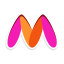

In [6]:
print(soup.prettify())

In [9]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/women-jeans"
driver.get(url)

time.sleep(10)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [10]:
print(items[0].prettify())

<li class="product-base" id="39033684">
 <div class="product-thumbShim">
 </div>
 <div class="product-ratingsContainer">
  <span>
   3.9
  </span>
  <span class="myntraweb-sprite product-starIcon index-productRatingsGoodIcon sprites-productRatingsGoodIcon">
  </span>
  <div class="product-ratingsCount">
   <div class="product-separator">
    |
   </div>
   <!-- react-text: 386 -->
   3.9k
   <!-- /react-text -->
  </div>
 </div>
 <a data-refreshpage="true" href="jeans/kashianxstyle/kashianxstyle-women-relaxed-fit-high-rise-jeans/39033684/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(255, 242, 223);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_

In [11]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [12]:
print(title[:3])
print(price[:3])
print(image_urls[:3])

['Women Relaxed Fit High-Rise Jeans', 'Women Relaxed Fit High-Rise Jeans', 'Women Wide Leg High-Rise Jeans']
['Rs. 392Rs. 1999(80% OFF)', 'Rs. 392Rs. 1999(80% OFF)', 'Rs. 599Rs. 2499(76% OFF)']
['https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/DECEMBER/29/KkoKiL8r_e6a8264ab26c496eb589b49511644599.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/DECEMBER/29/wCCJB6qQ_b9c40816c93b499e9e5d7d2f2276adbf.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2024/SEPTEMBER/15/NpVklfoE_d170c7c685794de4a45be6fcc39e524b.jpg']


In [13]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [23]:
df_jeans=pd.DataFrame(d)

In [24]:
df_jeans.head()

,title,brand,rating,price,size,rating_count,image_url
0,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9|3.9k,Rs. 392Rs. 1999(80% OFF),Sizes: 28,|3.9k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9|3.9k,Rs. 392Rs. 1999(80% OFF),Sizes: 28,|3.9k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Wide Leg High-Rise Jeans,Kotty,4|2.7k,Rs. 599Rs. 2499(76% OFF),Sizes: 26,|2.7k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9|3.9k,Rs. 392Rs. 1999(80% OFF),Sizes: 32,|3.9k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Women Wide Leg High-Rise Jeans,Chemistry,None,Rs. 732Rs. 2999(76% OFF),Sizes: 30,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [25]:
print(df_jeans.shape)

(50, 7)


In [26]:
df_jeans["rating"] = df_jeans["rating"].str.split("|").str[0]
df_jeans["rating_count"] = df_jeans["rating_count"].str.split("|").str[1]

In [27]:
df_jeans["size"] = df_jeans["size"].str.split(":").str[1]
df_jeans["current_price"] = (
    df_jeans["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)
df_jeans["original_price"] = (
    df_jeans["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)
df_jeans["discount"] = (
    df_jeans["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)
df_jeans["category"]= 'jeans'

In [28]:
df_jeans.sample(3)

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,Rs. 392Rs. 1999(80% OFF),28,3.9k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,80% OFF,jeans
3,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,Rs. 392Rs. 1999(80% OFF),32,3.9k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,80% OFF,jeans
27,Women Wide Leg High-Rise Jeans,Miss Chase A+,4.3,Rs. 1078Rs. 4495(76% OFF),40,1.4k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1078,4495,76% OFF,jeans


In [29]:
df_jeans.isnull().sum()

title             0
brand             0
rating            9
price             0
size              0
rating_count      9
image_url         0
current_price     0
original_price    1
discount          1
category          0
dtype: int64

In [30]:
df_jeans.drop(columns=["price"], inplace=True)

In [31]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [32]:
df_jeans['product_url']= product_url

In [33]:
df_jeans_copy= df_jeans.copy()

In [34]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_jeans["rating_count"] = df_jeans["rating_count"].apply(convert_count)

In [35]:
df_jeans.sample(5)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
44,Women Solid Straight Fit Jeans,Tokyo Talkies,4.3,34,1400.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",764,2549,70% OFF,jeans,https://www.myntra.com/jeans/tokyo+talkies/tok...
16,Women Wide Leg High-Rise Jeans,Chemistry,None,28,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732,2999,76% OFF,jeans,https://www.myntra.com/jeans/chemistry/chemist...
41,Women Wide Leg High-Rise Jeans,Off Duty India,4.2,26,120.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1689,1690,Rs. 1 OFF,jeans,https://www.myntra.com/jeans/off+duty+india/of...
46,Women Wide Leg High-Rise Jeans,Chemistry,None,32,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732,2999,76% OFF,jeans,https://www.myntra.com/jeans/chemistry/chemist...
34,Women Wide Leg High-Rise Jeans,Chemistry,None,32,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732,2999,76% OFF,jeans,https://www.myntra.com/jeans/chemistry/chemist...


In [36]:
df_jeans["rating"] = pd.to_numeric(df_jeans["rating"], errors="coerce")
df_jeans["current_price"] = pd.to_numeric(df_jeans["current_price"], errors="coerce")
df_jeans["original_price"] = pd.to_numeric(df_jeans["original_price"], errors="coerce")

In [37]:
df_jeans["rating_count"] = df_jeans["rating_count"].fillna(0).astype(int)

In [38]:
df_jeans["original_price"] = (
    df_jeans["original_price"]
    .fillna(0)
    .astype(int)
)

In [40]:
df_jeans.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,28,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,80% OFF,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...
1,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,28,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,80% OFF,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...
2,Women Wide Leg High-Rise Jeans,Kotty,4.0,26,2700,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,2499,76% OFF,jeans,https://www.myntra.com/jeans/kotty/kotty-women...
3,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,32,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,80% OFF,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...
4,Women Wide Leg High-Rise Jeans,Chemistry,NaN,30,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732,2999,76% OFF,jeans,https://www.myntra.com/jeans/chemistry/chemist...


In [41]:
df_jeans["discount_percent"] = (
    (
        df_jeans["original_price"] -
        df_jeans["current_price"]
    )
    / df_jeans["original_price"]
) * 100

In [42]:
df_jeans["discount_percent"] = (
    df_jeans["discount_percent"]
    .round(2)
)

In [43]:
df_jeans = df_jeans.drop("discount", axis=1)

In [44]:
df_jeans.sample(3)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,category,product_url,discount_percent
1,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,28,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392,1999,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...,80.39
10,Women Bootcut High-Rise Jeans,Chemistry,NaN,34,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732,2999,jeans,https://www.myntra.com/jeans/chemistry/chemist...,75.59
6,Women High-Rise Jeans,Aadvi Fashion,4.2,30,6800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",659,2999,jeans,https://www.myntra.com/jeans/aadvi+fashion/aad...,78.03


In [45]:
df_jeans['current_price']=df_jeans['current_price'].astype(float)

In [46]:
df_jeans.describe()

,rating,rating_count,current_price,original_price,discount_percent
count,41.000000,50.000000,50.000000,50.000000,50.0000
mean,4.068293,2473.640000,768.760000,2622.740000,-inf
std,0.265931,3432.287271,307.322775,747.143125,NaN
min,3.100000,0.000000,245.000000,0.000000,-inf
25%,3.900000,166.750000,609.000000,2011.500000,67.0200
50%,4.100000,1100.000000,732.000000,2524.000000,75.5900
75%,4.300000,3825.000000,913.000000,2999.000000,77.0375
max,4.400000,16700.000000,1689.000000,4495.000000,88.0400


In [49]:
df_jeans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            41 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    50 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  50 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [48]:
df_jeans['original_price']= df_jeans['original_price'].astype(float)

In [50]:
df_jeans.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,category,product_url,discount_percent
0,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,28,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392.0,1999.0,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...,80.39
1,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,28,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392.0,1999.0,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...,80.39
2,Women Wide Leg High-Rise Jeans,Kotty,4.0,26,2700,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599.0,2499.0,jeans,https://www.myntra.com/jeans/kotty/kotty-women...,76.03
3,Women Relaxed Fit High-Rise Jeans,KASHIANXSTYLE,3.9,32,3900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",392.0,1999.0,jeans,https://www.myntra.com/jeans/kashianxstyle/kas...,80.39
4,Women Wide Leg High-Rise Jeans,Chemistry,NaN,30,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",732.0,2999.0,jeans,https://www.myntra.com/jeans/chemistry/chemist...,75.59


In [51]:
df_jeans.to_csv("looped_jeans_data.csv", index=False)